# **NOTEBOOK 1: ALIE MODEL DEVELOPMENT**

# **PHASE 1: UNDERSTANDING THE DATASET**

**1. DATASET UPLOADATION**

In [67]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows",100)

print("Pandas Version: ", pd.__version__)
print("Numpy Version: ", pd.__version__)

Pandas Version:  2.2.2
Numpy Version:  2.2.2


In [68]:
df = pd.read_csv("master_learning_dataset.csv")

In [69]:
df.shape

(32593, 46)

In [70]:
print("StudentInfo: The Base Table")
print("Shape: ", df.shape)
print("\nColumns: ")
print(df.columns.tolist())

print("Few of the first rows are: ")
print(df.head())

StudentInfo: The Base Table
Shape:  (32593, 46)

Columns: 
['id_student', 'code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'studied_credits', 'num_of_prev_attempts', 'date_registration', 'dropped_out', 'avg_score', 'weighted_avg_score', 'last_score', 'n_assessments_attempted', 'n_banked_attempts', 'avg_days_to_submit', 'total_clicks', 'n_topics_completed', 'n_activity_types_used', 'engagement_days', 'progress_ratio', 'clicks_dataplus', 'clicks_dualpane', 'clicks_externalquiz', 'clicks_folder', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page', 'clicks_questionnaire', 'clicks_quiz', 'clicks_repeatactivity', 'clicks_resource', 'clicks_sharedsubpage', 'clicks_subpage', 'clicks_url', 'last_recommended_topic_proxy', 'final_result']
Few of the first rows are: 
   id_student code_module code_presentatio

In [71]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 46 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_student                    32593 non-null  int64  
 1   code_module                   32593 non-null  object 
 2   code_presentation             32593 non-null  object 
 3   gender                        32593 non-null  object 
 4   region                        32593 non-null  object 
 5   highest_education             32593 non-null  object 
 6   imd_band                      32593 non-null  object 
 7   age_band                      32593 non-null  object 
 8   disability                    32593 non-null  object 
 9   studied_credits               32593 non-null  int64  
 10  num_of_prev_attempts          32593 non-null  int64  
 11  date_registration             32593 non-null  float64
 12  dropped_out                   32593 non-null  int64  
 13  a

**2. DATA** **PREPROCESSING**

In [72]:
print("Numerical Catgeories: ")
print(df.describe())

print("Null Categories: ")
print(df.isnull().sum())

print("Duplicate Categories:")
print(df.duplicated().sum())

Numerical Catgeories: 
         id_student  studied_credits  num_of_prev_attempts  date_registration  \
count  3.259300e+04     32593.000000          32593.000000       32593.000000   
mean   7.066877e+05        79.758691              0.163225         -69.394164   
std    5.491673e+05        41.071900              0.479758          49.228660   
min    3.733000e+03        30.000000              0.000000        -322.000000   
25%    5.085730e+05        60.000000              0.000000        -100.000000   
50%    5.903100e+05        60.000000              0.000000         -57.000000   
75%    6.444530e+05       120.000000              0.000000         -29.000000   
max    2.716795e+06       655.000000              6.000000         167.000000   

        dropped_out     avg_score  weighted_avg_score    last_score  \
count  32593.000000  32593.000000        32593.000000  32593.000000   
mean       0.309023     57.839692           42.670736     56.686681   
std        0.462098     32.943312 

In [73]:
print(df.groupby("final_result")[["avg_score",
                                  "weighted_avg_score",
                                  "last_score"]].mean().round(2))

              avg_score  weighted_avg_score  last_score
final_result                                           
Distinction       88.43               81.53       89.29
Fail              52.77               25.36       50.76
Pass              76.38               71.67       74.75
Withdrawn         29.69                7.82       29.11


In [74]:
pd.crosstab(df["dropped_out"], df["final_result"])
df = df.drop(columns=["id_student"])


In [75]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print("=" * 60)
    print(f"Column: {col}")
    print("Unique Values:")
    print(df[col].value_counts(dropna=False))
    print("\n")

Column: code_module
Unique Values:
code_module
BBB    7909
FFF    7762
DDD    6272
CCC    4434
EEE    2934
GGG    2534
AAA     748
Name: count, dtype: int64


Column: code_presentation
Unique Values:
code_presentation
2014J    11260
2013J     8845
2014B     7804
2013B     4684
Name: count, dtype: int64


Column: gender
Unique Values:
gender
M    17875
F    14718
Name: count, dtype: int64


Column: region
Unique Values:
region
Scotland                3446
East Anglian Region     3340
London Region           3216
South Region            3092
North Western Region    2906
West Midlands Region    2582
South West Region       2436
East Midlands Region    2365
South East Region       2111
Wales                   2086
Yorkshire Region        2006
North Region            1823
Ireland                 1184
Name: count, dtype: int64


Column: highest_education
Unique Values:
highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                

In [76]:
X = df.drop(columns=["dropped_out", "final_result"])

y = df["final_result"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (32593, 43)
Target Shape : (32593,)


In [77]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()

numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features")
print(categorical_cols)

print("\nNumber of Categorical Features :", len(categorical_cols))

print("\nNumerical Features")
print(numerical_cols)

print("\nNumber of Numerical Features :", len(numerical_cols))

Categorical Features
['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'last_recommended_topic_proxy']

Number of Categorical Features : 9

Numerical Features
['studied_credits', 'num_of_prev_attempts', 'date_registration', 'avg_score', 'weighted_avg_score', 'last_score', 'n_assessments_attempted', 'n_banked_attempts', 'avg_days_to_submit', 'total_clicks', 'n_topics_completed', 'n_activity_types_used', 'engagement_days', 'progress_ratio', 'clicks_dataplus', 'clicks_dualpane', 'clicks_externalquiz', 'clicks_folder', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page', 'clicks_questionnaire', 'clicks_quiz', 'clicks_repeatactivity', 'clicks_resource', 'clicks_sharedsubpage', 'clicks_subpage', 'clicks_url']

Number of Numerical Features : 34


In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(26074, 43)
(6519, 43)


In [79]:
onehot_cols = [
    "code_module",
    "code_presentation",
    "gender",
    "region",
    "disability",
    "last_recommended_topic_proxy"
]

In [80]:
ordinal_cols = [
    "highest_education",
    "imd_band",
    "age_band"
]

In [81]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [82]:
education_order = [
    "No Formal quals",
    "Lower Than A Level",
    "A Level or Equivalent",
    "HE Qualification",
    "Post Graduate Qualification"
]

imd_order = [
    "Unknown",
    "0-10%",
    "10-20%",
    "20-30%",
    "30-40%",
    "40-50%",
    "50-60%",
    "60-70%",
    "70-80%",
    "80-90%",
    "90-100%"
]

age_order = [
    "0-35",
    "35-55",
    "55<="
]

In [83]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore"),
            onehot_cols
        ),

        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    education_order,
                    imd_order,
                    age_order
                ]
            ),
            ordinal_cols
        ),

        (
            "num",
            StandardScaler(),
            numerical_cols
        )

    ]
)

In [84]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(26074, 78)
(6519, 78)


**3. DATA VALIDATION**

In [85]:
print("X_train: ", X_train_processed.shape)
print("X_test: ", X_test_processed.shape)
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)

X_train:  (26074, 78)
X_test:  (6519, 78)
y_train:  (26074,)
y_test:  (6519,)


In [86]:
print("Training Distribution")
print(y_train.value_counts(normalize=True))

print()

print("Testing Distribution")
print(y_test.value_counts(normalize=True))

Training Distribution
final_result
Pass           0.379267
Withdrawn      0.311613
Fail           0.216346
Distinction    0.092774
Name: proportion, dtype: float64

Testing Distribution
final_result
Pass           0.379199
Withdrawn      0.311551
Fail           0.216444
Distinction    0.092806
Name: proportion, dtype: float64


In [87]:
import numpy as np
print(np.isnan(X_train_processed).sum())
print(np.isnan(X_test_processed).sum())

print(type(X_train_processed))
print(type(X_test_processed))
print(X_train_processed.shape[1])

0
0
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
78


# **PHASE 2: METHODICAL MACHINE LEARNING**

**1. LOGISTIC REGRESSION**

In [88]:
from sklearn.linear_model import LogisticRegression

In [89]:
log_model = LogisticRegression(
    max_iter = 1000,
    random_state = 42
)

log_model.fit(X_train_processed,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [90]:
y_pred = log_model.predict(X_test_processed)

In [91]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7449


In [92]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

 Distinction       0.67      0.48      0.56       605
        Fail       0.61      0.43      0.50      1411
        Pass       0.78      0.91      0.84      2472
   Withdrawn       0.77      0.84      0.80      2031

    accuracy                           0.74      6519
   macro avg       0.71      0.66      0.68      6519
weighted avg       0.73      0.74      0.73      6519



In [93]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 288    2  315    0]
 [   4  603  294  510]
 [ 140   77 2251    4]
 [   0  303   14 1714]]


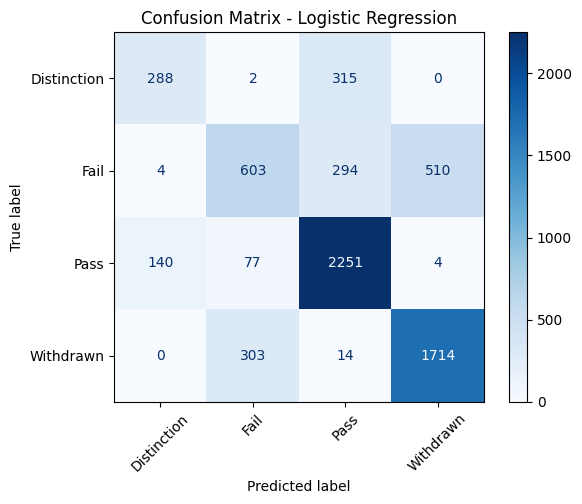

In [94]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test_processed,
    y_test,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**2. RANDOM FOREST**

In [95]:
from sklearn.ensemble import RandomForestClassifier

In [96]:
rf_model = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42,
    n_jobs = -1
)

In [97]:
rf_model.fit(X_train_processed,y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [98]:
rf_pred = rf_model.predict(X_test_processed)

In [99]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy : {rf_accuracy:.4f}")

Random Forest Accuracy : 0.7506


In [100]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

 Distinction       0.73      0.46      0.57       605
        Fail       0.63      0.41      0.49      1411
        Pass       0.78      0.94      0.85      2472
   Withdrawn       0.77      0.85      0.81      2031

    accuracy                           0.75      6519
   macro avg       0.72      0.66      0.68      6519
weighted avg       0.74      0.75      0.73      6519



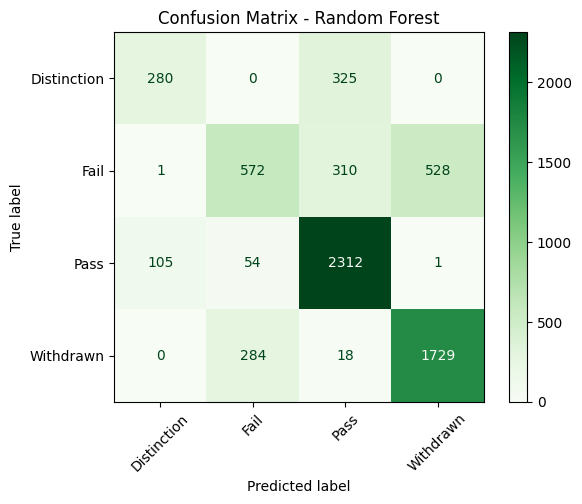

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test_processed,
    y_test,
    cmap="Greens",
    xticks_rotation=45
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [102]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
57,num__progress_ratio,0.119026
52,num__avg_days_to_submit,0.097532
48,num__weighted_avg_score,0.078451
47,num__avg_score,0.066953
50,num__n_assessments_attempted,0.051523
49,num__last_score,0.043188
56,num__engagement_days,0.041865
53,num__total_clicks,0.036547
64,num__clicks_homepage,0.030999
54,num__n_topics_completed,0.030408


**3. HYPERPARAMETER TUNING**

In [103]:
from sklearn.ensemble import RandomForestClassifier

rf_tuned = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train_processed, y_train)
rf_tuned_pred = rf_tuned.predict(X_test_processed)

In [104]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy : {rf_accuracy:.4f}")

Random Forest Accuracy : 0.7506


In [105]:
from sklearn.metrics import balanced_accuracy_score

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, rf_pred))

Balanced Accuracy: 0.6636940062799612


**4. XGBOOST**

In [106]:
!pip install xgboost -q


In [107]:
from xgboost import XGBClassifier

In [108]:
xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=4,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

In [109]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [110]:
xgb_model.fit(
    X_train_processed,
    y_train_encoded
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=4, ...)

In [111]:
pred = xgb_model.predict(X_test_processed)
pred = label_encoder.inverse_transform(pred)

xgb_pred = xgb_model.predict(
    X_test_processed
)

In [112]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test_encoded,
    xgb_pred
)

print(f"XGBoost Accuracy : {accuracy:.4f}")

XGBoost Accuracy : 0.7563


In [113]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_encoded,
        xgb_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

 Distinction       0.69      0.53      0.60       605
        Fail       0.62      0.46      0.53      1411
        Pass       0.80      0.91      0.85      2472
   Withdrawn       0.78      0.84      0.81      2031

    accuracy                           0.76      6519
   macro avg       0.72      0.69      0.70      6519
weighted avg       0.74      0.76      0.74      6519



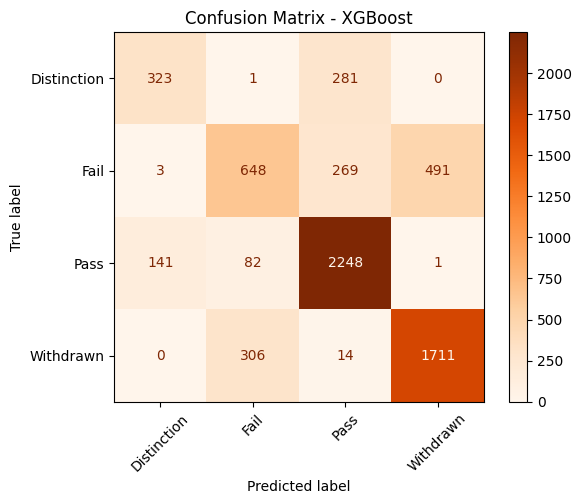

In [114]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    xgb_pred,
    display_labels=label_encoder.classes_,
    cmap="Oranges",
    xticks_rotation=45
)

plt.title("Confusion Matrix - XGBoost")
plt.show()

# **PHASE 3: PRELIMINARY ENGINE BUILDUP**

**1. FACTOR CONSIDERATIONS**

In [115]:
probabilities = xgb_model.predict_proba(X_test_processed)
print(probabilities.shape)
probabilities[:5]


(6519, 4)


array([[2.1714149e-03, 7.4874246e-01, 9.4512356e-03, 2.3963480e-01],
       [2.3533666e-01, 1.9496536e-02, 7.4332327e-01, 1.8435845e-03],
       [1.3604297e-04, 1.7333470e-01, 2.8195619e-04, 8.2624733e-01],
       [4.6425284e-05, 2.0624889e-02, 8.6690852e-05, 9.7924197e-01],
       [1.9953442e-03, 2.9851949e-01, 6.9771701e-01, 1.7681345e-03]],
      dtype=float32)

In [116]:
import pandas as pd

prob_df = pd.DataFrame(probabilities,columns=label_encoder.classes_)
prob_df.head(10)

,Distinction,Fail,Pass,Withdrawn
0,0.002171,0.748742,0.009451,0.239635
1,0.235337,0.019497,0.743323,0.001844
2,0.000136,0.173335,0.000282,0.826247
3,0.000046,0.020625,0.000087,0.979242
4,0.001995,0.298519,0.697717,0.001768
5,0.080600,0.024350,0.892959,0.002090
6,0.787542,0.002048,0.210188,0.000222
7,0.000157,0.409073,0.000255,0.590516
8,0.012684,0.073370,0.913461,0.000485
9,0.000244,0.591470,0.000620,0.407666


In [117]:
results = X_test.reset_index(drop=True).copy()

results["Actual"] = y_test.reset_index(drop=True)

results["Prediction"] = label_encoder.inverse_transform(xgb_pred)

results = pd.concat(
    [
        results,
        prob_df
    ],
    axis=1
)

results.head()

,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,disability,studied_credits,num_of_prev_attempts,date_registration,avg_score,weighted_avg_score,last_score,n_assessments_attempted,n_banked_attempts,avg_days_to_submit,total_clicks,n_topics_completed,n_activity_types_used,engagement_days,progress_ratio,clicks_dataplus,clicks_dualpane,clicks_externalquiz,clicks_folder,clicks_forumng,clicks_glossary,clicks_homepage,clicks_htmlactivity,clicks_oucollaborate,clicks_oucontent,clicks_ouelluminate,clicks_ouwiki,clicks_page,clicks_questionnaire,clicks_quiz,clicks_repeatactivity,clicks_resource,clicks_sharedsubpage,clicks_subpage,clicks_url,last_recommended_topic_proxy,Actual,Prediction,Distinction,Fail,Pass,Withdrawn
0,GGG,2014B,F,South West Region,Lower Than A Level,40-50%,35-55,Y,30,0,-29.0,80.666667,0.00,100.0,3.0,0.0,82.333333,420.0,38.0,7.0,32.0,0.655602,0.0,0.0,0.0,0.0,72.0,1.0,96.0,0.0,0.0,150.0,0.0,0.0,0.0,0.0,35.0,0.0,43.0,0.0,23.0,0.0,oucontent,Fail,Fail,0.002171,0.748742,0.009451,0.239635
1,BBB,2013J,F,Scotland,HE Qualification,40-50%,35-55,N,120,0,-92.0,83.181818,79.76,80.0,11.0,0.0,122.272727,993.0,43.0,7.0,86.0,0.929104,0.0,0.0,0.0,0.0,618.0,0.0,246.0,0.0,0.0,16.0,0.0,0.0,0.0,0.0,67.0,0.0,20.0,0.0,18.0,8.0,forumng,Pass,Pass,0.235337,0.019497,0.743323,0.001844
2,FFF,2014J,M,North Region,Lower Than A Level,10-20%,0-35,N,120,0,-155.0,64.000000,8.00,64.0,1.0,0.0,20.000000,236.0,42.0,10.0,9.0,0.141264,0.0,0.0,0.0,0.0,97.0,0.0,29.0,6.0,0.0,32.0,0.0,1.0,2.0,0.0,9.0,0.0,7.0,0.0,44.0,9.0,forumng,Fail,Withdrawn,0.000136,0.173335,0.000282,0.826247
3,FFF,2014J,M,East Anglian Region,Lower Than A Level,20-30%,0-35,N,120,0,-144.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,dataplus,Withdrawn,Withdrawn,0.000046,0.020625,0.000087,0.979242
4,DDD,2014B,M,East Anglian Region,Lower Than A Level,90-100%,0-35,N,60,0,-29.0,50.285714,95.55,47.0,7.0,0.0,123.142857,799.0,57.0,9.0,77.0,0.946058,0.0,0.0,1.0,0.0,178.0,0.0,206.0,0.0,9.0,295.0,0.0,33.0,0.0,0.0,0.0,0.0,20.0,0.0,49.0,8.0,oucontent,Fail,Pass,0.001995,0.298519,0.697717,0.001768


In [118]:
important_features = [
    "avg_score",
    "progress_ratio",
    "total_clicks",
    "clicks_quiz",
    "n_assessments_attempted",
    "engagement_days"
]

df[important_features].describe()

,avg_score,progress_ratio,total_clicks,clicks_quiz,n_assessments_attempted,engagement_days
count,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000
mean,57.839692,0.621570,1215.141257,214.194459,5.247967,55.475685
std,32.943312,0.391465,1692.604449,447.554985,4.290127,54.515290
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,43.333333,0.190299,142.000000,0.000000,1.000000,11.000000
50%,70.888889,0.873134,602.000000,56.000000,5.000000,40.000000
75%,82.500000,0.958506,1585.000000,178.000000,9.000000,85.000000
max,100.000000,1.000000,24139.000000,13032.000000,14.000000,286.000000


In [119]:
importance_order = [
    "progress_ratio",
    "avg_days_to_submit",
    "weighted_avg_score",
    "avg_score",
    "n_assessments_attempted",
    "last_score",
    "engagement_days",
    "total_clicks",
    "n_topics_completed",
    "clicks_quiz",
    "clicks_resource",
    "clicks_oucontent"
]

**2. FUNCTIONAL CHARACTERIZATION**

In [120]:
import pandas as pd

recommendation_kb = pd.DataFrame({
    "Recommendation_ID": [
        "R1", "R2", "R3", "R4", "R5", "R6", "R7"
    ],

    "Learning_Dimension": [
        "Quiz Performance",
        "Learning Progress",
        "Engagement",
        "Assessment Behaviour",
        "Submission Behaviour",
        "Topic Coverage",
        "Previous Recommendation"
    ],

    "Trigger": [
        "Low Quiz Score",
        "Low Progress",
        "Low Engagement",
        "Few Assessment Attempts",
        "Late Submission",
        "Few Topics Completed",
        "Repeated Recommendation"
    ],

    "Recommendation": [
        "Practice more quizzes",
        "Complete pending learning topics",
        "Spend more time on learning resources",
        "Attempt remaining assessments",
        "Submit assessments earlier",
        "Cover unfinished learning topics",
        "Try a different learning strategy"
    ],

    "Suggested_Resource": [
        "Quiz Portal",
        "Learning Modules",
        "Course Resources",
        "Assessment Section",
        "Submission Planner",
        "Topic Library",
        "Personalized Study Plan"
    ],

    "Priority": [
        "High",
        "High",
        "Medium",
        "High",
        "Medium",
        "High",
        "Low"
    ]
})

recommendation_kb

,Recommendation_ID,Learning_Dimension,Trigger,Recommendation,Suggested_Resource,Priority
0,R1,Quiz Performance,Low Quiz Score,Practice more quizzes,Quiz Portal,High
1,R2,Learning Progress,Low Progress,Complete pending learning topics,Learning Modules,High
2,R3,Engagement,Low Engagement,Spend more time on learning resources,Course Resources,Medium
3,R4,Assessment Behaviour,Few Assessment Attempts,Attempt remaining assessments,Assessment Section,High
4,R5,Submission Behaviour,Late Submission,Submit assessments earlier,Submission Planner,Medium
5,R6,Topic Coverage,Few Topics Completed,Cover unfinished learning topics,Topic Library,High
6,R7,Previous Recommendation,Repeated Recommendation,Try a different learning strategy,Personalized Study Plan,Low


In [121]:
df["time_per_topic"] = (df["engagement_days"]/df["n_topics_completed"].replace(0,1))
df["time_per_topic"].describe()

,time_per_topic
count,32593.000000
mean,0.847558
std,0.628119
min,0.000000
25%,0.466667
50%,0.750000
75%,1.102564
max,6.586207


In [122]:

def build_learning_profile(student):

    profile = {}

    if student["avg_score"] >= 80:
        profile["Quiz"] = "Excellent"

    elif student["avg_score"] >= 60:
        profile["Quiz"] = "Good"

    elif student["avg_score"] >= 40:
        profile["Quiz"] = "Average"

    else:
        profile["Quiz"] = "Needs Improvement"

    if student["progress_ratio"] >= 0.90:
        profile["Progress"] = "Excellent"

    elif student["progress_ratio"] >= 0.70:
        profile["Progress"] = "Good"

    elif student["progress_ratio"] >= 0.40:
        profile["Progress"] = "Moderate"

    else:
        profile["Progress"] = "Low"

    if student["n_topics_completed"] >= 70:
        profile["Topics"] = "Excellent"

    elif student["n_topics_completed"] >= 50:
        profile["Topics"] = "Good"

    elif student["n_topics_completed"] >= 25:
        profile["Topics"] = "Moderate"

    else:
        profile["Topics"] = "Low"

    if student["total_clicks"] >= 1500:
        profile["Engagement"] = "High"

    elif student["total_clicks"] >= 600:
        profile["Engagement"] = "Medium"

    else:
        profile["Engagement"] = "Low"

    tpt = student["time_per_topic"]

    if tpt <= 0.47:
        profile["Study Behaviour"] = "Very Fast"

    elif tpt <= 0.75:
        profile["Study Behaviour"] = "Balanced"

    elif tpt <= 1.10:
        profile["Study Behaviour"] = "Careful"

    else:
        profile["Study Behaviour"] = "Very Detailed"


    return profile

In [123]:
student = df.iloc[0]

profile = build_learning_profile(student)
profile

{'Quiz': 'Excellent',
 'Progress': 'Excellent',
 'Topics': 'Good',
 'Engagement': 'Medium',
 'Study Behaviour': 'Balanced'}

In [124]:

def calculate_health_score(profile):

    score = 0

    quiz_scores = {
        "Excellent":20,
        "Good":15,
        "Average":10,
        "Needs Improvement":5
    }

    score += quiz_scores[profile["Quiz"]]

    progress_scores = {
        "Excellent":20,
        "Good":15,
        "Moderate":10,
        "Low":5
    }

    score += progress_scores[profile["Progress"]]

    topic_scores = {
        "Excellent":20,
        "Good":15,
        "Moderate":10,
        "Low":5
    }

    score += topic_scores[profile["Topics"]]

    engagement_scores = {
        "High":20,
        "Medium":15,
        "Low":5
    }

    score += engagement_scores[profile["Engagement"]]

    behaviour_scores = {
        "Balanced":20,
        "Careful":18,
        "Very Detailed":15,
        "Very Fast":10
    }

    score += behaviour_scores[profile["Study Behaviour"]]

    return score

In [125]:
student = df.iloc[0]

profile = build_learning_profile(student)

health = calculate_health_score(profile)

print(profile)
print("Learning Health Score :", health)

{'Quiz': 'Excellent', 'Progress': 'Excellent', 'Topics': 'Good', 'Engagement': 'Medium', 'Study Behaviour': 'Balanced'}
Learning Health Score : 90


In [126]:

def generate_recommendations(profile):

    recommendations = []

    if profile["Quiz"] == "Needs Improvement":

        recommendations.append(
            recommendation_kb.iloc[0]
        )

    if profile["Progress"] == "Low":

        recommendations.append(
            recommendation_kb.iloc[1]
        )

    if profile["Engagement"] == "Low":

        recommendations.append(
            recommendation_kb.iloc[2]
        )

    if profile["Topics"] == "Low":

        recommendations.append(
            recommendation_kb.iloc[5]
        )

    if len(recommendations) == 0:

        recommendations.append({

            "Recommendation":
            "Continue your current learning strategy",

            "Suggested_Resource":
            "Advanced Learning Modules",

            "Priority":
            "Low"

        })

    return recommendations

In [127]:
recommendations = generate_recommendations(profile)

recommendations

[{'Recommendation': 'Continue your current learning strategy',
  'Suggested_Resource': 'Advanced Learning Modules',
  'Priority': 'Low'}]

**3. PREQUISITES AND THRESHOLD**


In [128]:
def detect_persona(profile):

    if (
        profile["Quiz"] == "Excellent"
        and profile["Progress"] == "Excellent"
    ):
        return "Consistent Learner"

    elif (
        profile["Engagement"] == "Low"
        and profile["Progress"] == "Low"
    ):
        return "At-Risk Learner"

    elif (
        profile["Engagement"] == "High"
        and profile["Quiz"] != "Excellent"
    ):
        return "Hardworking Learner"

    elif (
        profile["Study Behaviour"] == "Very Detailed"
    ):
        return "Deep Learner"

    else:
        return "Balanced Learner"

In [129]:

engine_features = [
    "avg_score",
    "n_topics_completed",
    "engagement_days",
    "n_assessments_attempted",
    "progress_ratio",
]

importance_lookup = dict(zip(importance["Feature"], importance["Importance"]))

raw_weights = {
    feat: importance_lookup.get(f"num__{feat}", 0.01)
    for feat in engine_features
}

total_w = sum(raw_weights.values())
DIMENSION_WEIGHTS = {k: v / total_w for k, v in raw_weights.items()}

print("Model-driven dimension weights:")
for k, v in DIMENSION_WEIGHTS.items():
    print(f"  {k:28s} -> {v:.4f}")

Model-driven dimension weights:
  avg_score                    -> 0.2161
  n_topics_completed           -> 0.0982
  engagement_days              -> 0.1351
  n_assessments_attempted      -> 0.1663
  progress_ratio               -> 0.3842


In [130]:

POP_SORTED = {f: np.sort(df[f].dropna().values) for f in engine_features}

def percentile_rank(feature, value):
    arr = POP_SORTED[feature]
    idx = np.searchsorted(arr, value, side="right")
    return idx / len(arr)

In [131]:

import pandas as pd

subject_catalog = pd.DataFrame([

    {
        "Subject":"OOP",
        "Topic":"Classes and Objects",
        "Difficulty":"Beginner",
        "Resource":"Interactive Notes",
        "Recommended_When":"Low Quiz Score"
    },

    {
        "Subject":"OOP",
        "Topic":"Inheritance",
        "Difficulty":"Intermediate",
        "Resource":"Practice Problems",
        "Recommended_When":"Medium Progress"
    },

    {
        "Subject":"OOP",
        "Topic":"Polymorphism",
        "Difficulty":"Advanced",
        "Resource":"Coding Assignment",
        "Recommended_When":"High Progress"
    },

    {
        "Subject":"DBMS",
        "Topic":"SQL Basics",
        "Difficulty":"Beginner",
        "Resource":"Interactive SQL Lab",
        "Recommended_When":"Low Quiz Score"
    },

    {
        "Subject":"DBMS",
        "Topic":"Normalization",
        "Difficulty":"Intermediate",
        "Resource":"Concept Notes",
        "Recommended_When":"Medium Progress"
    },

    {
        "Subject":"DBMS",
        "Topic":"Transactions",
        "Difficulty":"Advanced",
        "Resource":"Mini Project",
        "Recommended_When":"High Progress"
    },

    {
        "Subject":"Machine Learning",
        "Topic":"Linear Regression",
        "Difficulty":"Beginner",
        "Resource":"Video + Notebook",
        "Recommended_When":"Low Progress"
    },

    {
        "Subject":"Machine Learning",
        "Topic":"Decision Trees",
        "Difficulty":"Intermediate",
        "Resource":"Practice Notebook",
        "Recommended_When":"Medium Progress"
    },

    {
        "Subject":"Machine Learning",
        "Topic":"XGBoost",
        "Difficulty":"Advanced",
        "Resource":"Case Study",
        "Recommended_When":"High Progress"
    }

])

subject_catalog.head()

,Subject,Topic,Difficulty,Resource,Recommended_When
0,OOP,Classes and Objects,Beginner,Interactive Notes,Low Quiz Score
1,OOP,Inheritance,Intermediate,Practice Problems,Medium Progress
2,OOP,Polymorphism,Advanced,Coding Assignment,High Progress
3,DBMS,SQL Basics,Beginner,Interactive SQL Lab,Low Quiz Score
4,DBMS,Normalization,Intermediate,Concept Notes,Medium Progress


# **MODEL EXTRACTION**

In [132]:
import joblib

joblib.dump(xgb_model, "xgboost_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']